# Laptop Price Prediction System:

Importing libraries:


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

Collecting the data:

In [3]:
df= pd.read_csv("laptop_data.csv")
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   str    
 2   TypeName          1303 non-null   str    
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   str    
 5   Cpu               1303 non-null   str    
 6   Ram               1303 non-null   str    
 7   Memory            1303 non-null   str    
 8   Gpu               1303 non-null   str    
 9   OpSys             1303 non-null   str    
 10  Weight            1303 non-null   str    
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), str(9)
memory usage: 261.0 KB


# Data Pre-Processing & EDA:

In [5]:
df.isnull().sum() # Check for missing values in each column

Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [6]:
df.duplicated().sum() # Check for duplicate rows in the dataset

np.int64(0)

In [7]:
df.drop(columns=['Unnamed: 0'], inplace=True) # Drop the 'Unnamed: 0' column as it is not needed

In [8]:
df.head(3) # Display the first 3 rows of the DataFrame to verify the changes

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000


In [9]:
df['Ram']= df['Ram'].str.replace('GB','').astype(int) # Remove 'GB' from the 'Ram' column and convert it to integer
df['Weight']= df['Weight'].str.replace('kg','').astype(float) # Remove 'kg' from the 'Weight' column and convert it to float

In [10]:
df.head(4) # Display the first 4 rows of the DataFrame to verify the changes

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360


Distribution of Price:


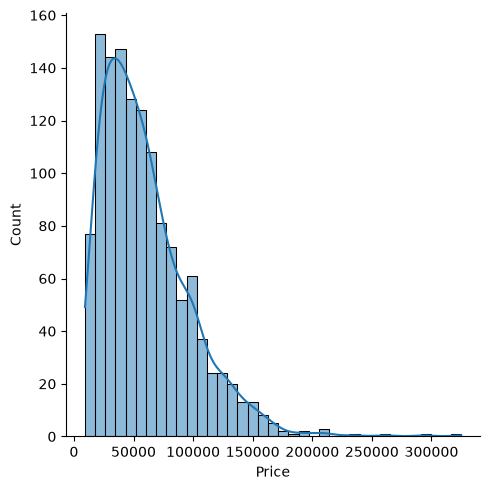

In [11]:
sns.displot(df['Price'],kde=True) # Plot the distribution of the 'Price' column with a kernel density estimate

Most selling companies:

<Axes: xlabel='Company'>

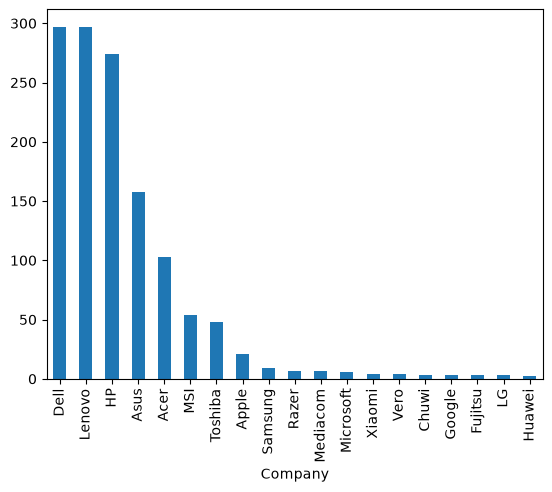

In [12]:
df['Company'].value_counts().plot(kind='bar') # Plot the count of laptops by company

Price Distribution based on companies:

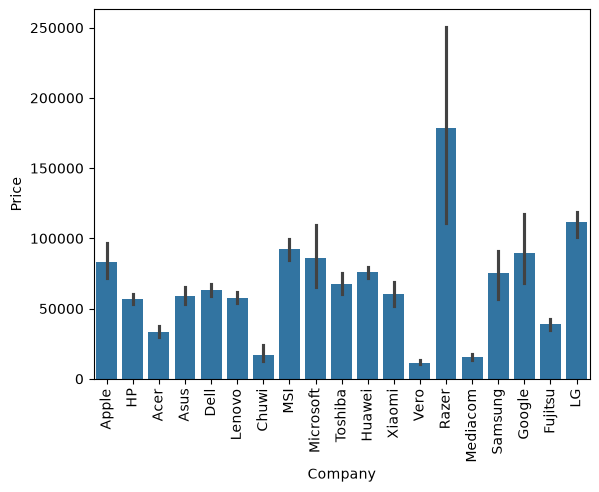

In [13]:
sns.barplot(x=df['Company'], y=df['Price']) # Create a bar plot showing the average price of laptops by company
plt.xticks(rotation='vertical') # Rotate the x-axis labels for better readability
plt.show() # Display the plot

Which type of laptops are sold mostly?

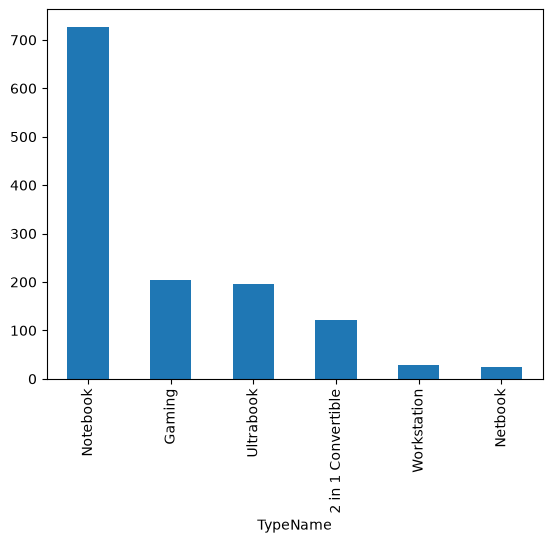

In [14]:
df['TypeName'].value_counts().plot(kind='bar') # Plot the count of laptops by type name
plt.show() # Display the plot

Which type of Laptops costs more?

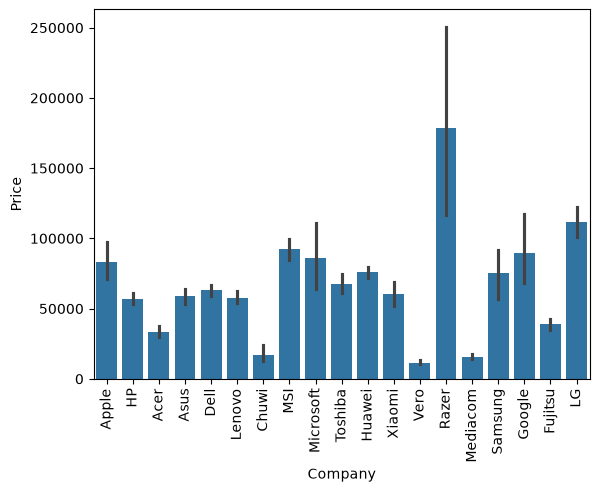

In [15]:
sns.barplot(x=df['Company'],y=df['Price']) # Create a bar plot of the average price of laptops by company
plt.xticks(rotation='vertical') # Rotate the x-axis labels for better readability
plt.show() # Display the plot

Distribution of screen size:

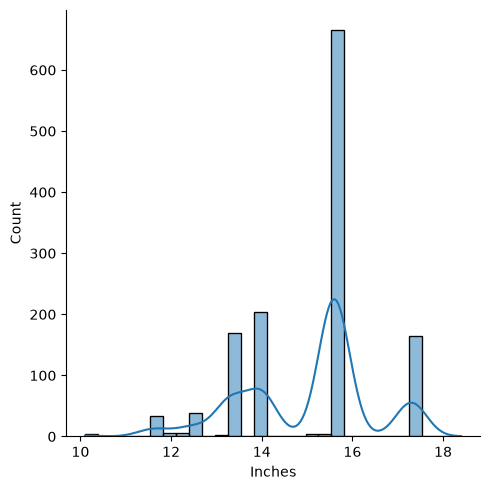

In [16]:
sns.displot(df['Inches'],kde=True) # Plot the distribution of the 'Inches' column with a kernel density estimate
plt.show() # Display the plot

Does Screensize afftects Price?


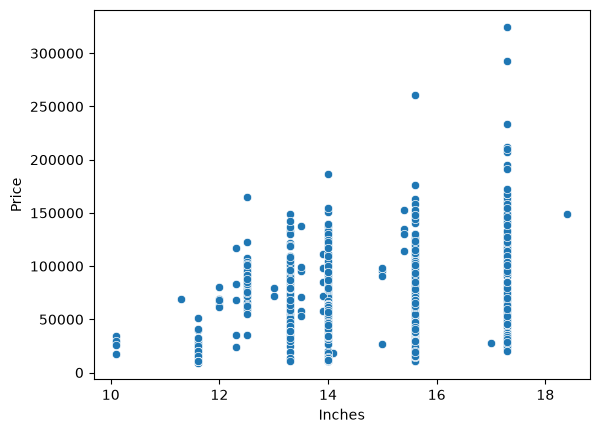

In [17]:
sns.scatterplot(x=df['Inches'],y=df['Price']) # Create a scatter plot of 'Inches' vs 'Price'
plt.show() # Display the plot

In [18]:
df['ScreenResolution'].value_counts() # Display the count of each unique value in the 'ScreenResolution' column


ScreenResolution
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
IPS Panel 1366x768                                 7
Touchscreen 2560x1440                              7
4K Ultra HD 3840x2160                              7
IPS Panel Retina Display 2560x1600                 6
IPS Panel Retina Display 2304x1440                 6
Touchscreen 2256x1504                              6
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Touchscreen 2560x14

In [19]:
df['TouchScreen']= df['ScreenResolution'].apply(lambda x: 1 if 'Touchscreen' in x else 0) # Create a new column 'TouchScreen' that indicates whether the laptop has a touchscreen or not (1 for touchscreen, 0 for non-touchscreen)

In [20]:
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen
834,Lenovo,Notebook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 7300U 2.6GHz,8,256GB SSD,Intel HD Graphics 620,Windows 10,1.32,87912.00,0
544,Asus,Notebook,15.6,1366x768,AMD E-Series 7110 1.8GHz,4,500GB HDD,AMD Radeon R2 Graphics,Windows 10,2.00,18594.72,0
249,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,512GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,108691.20,0
1097,MSI,Gaming,17.3,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,8,256GB SSD,Nvidia GeForce GTX 965M,Windows 10,2.60,85194.72,0
844,HP,Ultrabook,14.0,Full HD 1920x1080,Intel Core i7 6500U 2.5GHz,8,512GB SSD,Intel HD Graphics 520,Windows 7,1.54,99633.60,0


Frequency Distribution of Touchscreen Laptops:

<Axes: xlabel='TouchScreen'>

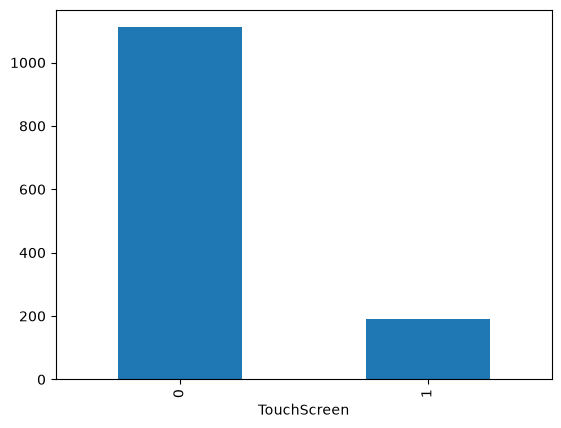

In [21]:
df['TouchScreen'].value_counts().plot(kind='bar') # Plot the count of laptops by touchscreen feature

Does TouchScreen Laptops cost More?

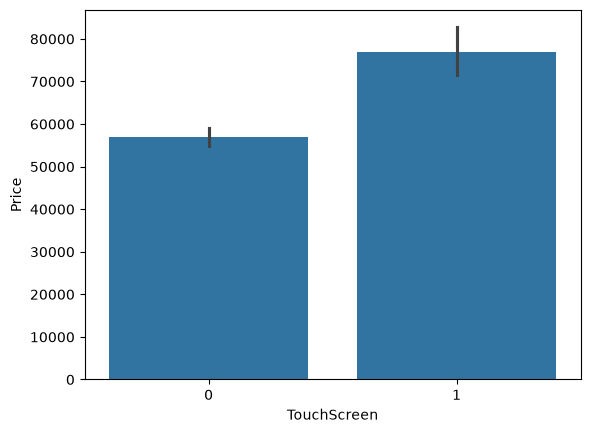

In [22]:
sns.barplot(x=df['TouchScreen'],y=df['Price']) # Create a bar plot of the average price of laptops by TouchScreen feature
plt.show() # Display the plot

In [23]:
df['Ips']= df['ScreenResolution'].apply(lambda x: 1 if 'IPS' in x else 0) # Create a new column 'Ips' that indicates whether the laptop has an IPS display or not (1 for IPS, 0 for non-IPS)

In [24]:
df.sample(5) # Display a random sample of 5 rows from the DataFrame to verify the changes

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,Ips
540,Dell,Ultrabook,13.3,Quad HD+ / Touchscreen 3200x1800,Intel Core i7 8550U 1.8GHz,8,256GB SSD,Intel UHD Graphics 620,Windows 10,1.20,74538.72,1,0
162,Dell,Notebook,15.6,Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8,256GB SSD,AMD Radeon 520,Windows 10,2.13,38787.84,0,0
633,Lenovo,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,4,1TB HDD,Nvidia GeForce 920MX,Windows 10,2.20,30849.12,0,0
126,HP,Notebook,14.0,Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8,1TB HDD,Intel UHD Graphics 620,Windows 10,1.63,43263.36,0,0
114,Dell,Ultrabook,13.3,IPS Panel Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8,256GB SSD,Intel UHD Graphics 620,Windows 10,1.21,86793.12,0,1


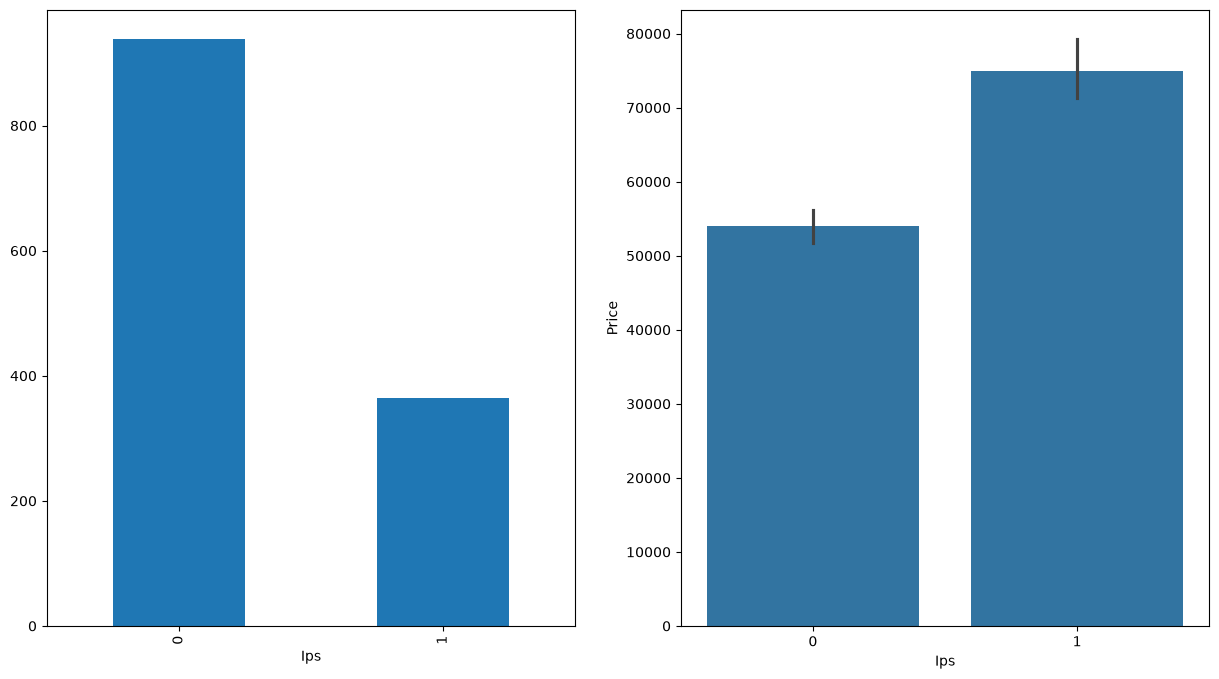

In [25]:
plt.subplots(1,2, figsize=(15,8)) # Create a figure with a specified size

plt.subplot(1,2,1) # Create the first subplot
df['Ips'].value_counts().plot(kind='bar') # Plot the count of laptops by IPS display feature

plt.subplot(1,2,2) # Create the second subplot
sns.barplot(x=df['Ips'],y=df['Price']) # Create a bar plot of the average price of laptops by IPS display feature

plt.show() # Display the plots

In [26]:
# Calculate the pixels per inch (PPI) for each laptop based on its screen resolution and size

new= df['ScreenResolution'].str.split('x', n=1, expand=True) # Split the 'ScreenResolution' column into two parts at the 'x' character
df['X_res']= new[0] # Assign the first part (X resolution) to
df['Y_res']= new[1] # Assign the second part (Y resolution) to a new column 'Y_res'

In [27]:
df.head(4) # Display the first 4 rows of the DataFrame to verify the changes

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,Ips,X_res,Y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,IPS Panel Retina Display 2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,Full HD 1920,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,IPS Panel Retina Display 2880,1800


In [28]:
import re

# Remove commas, extract first float-like number, convert to float
df['X_res'] = (
    df['X_res']
    .str.replace(',', '', regex=False)
    .apply(lambda s: float(re.search(r'\d+(\.\d+)?', s).group()) if pd.notnull(s) else None)
)

In [29]:
df.head(4) # Display the first 4 rows of the DataFrame to verify the changes

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,Ips,X_res,Y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560.0,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440.0,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920.0,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880.0,1800


In [30]:
df['X_res']= df['X_res'].astype(int) # Convert the 'X_res' column to integer type
df['Y_res']= df['Y_res'].astype(int) # Convert the 'Y_res' column to integer type

In [31]:
df.head(3) # Display the first 3 rows of the DataFrame to verify the changes

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,Ips,X_res,Y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080


In [32]:
df['ppi']= (((df['X_res']**2) + (df['Y_res']**2))**0.5 / df['Inches']).astype(float) # Calculate the pixels per inch (PPI) for each laptop and store it in a new column 'ppi'

In [33]:
df.drop(columns=['ScreenResolution','X_res','Y_res'], inplace=True) # Drop the 'ScreenResolution', 'X_res', and 'Y_res' columns as they are no longer needed

In [34]:
df.drop(columns=['Inches'], inplace=True) # Drop the 'Inches' column as it is no longer needed

In [35]:
df.head(4) # Display the first 4 rows of the DataFrame to verify the changes

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,Ips,ppi
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624


In [36]:
df['Cpu Name']= df['Cpu'].apply(lambda x: " ".join(x.split()[0:3]))
 # Extract the first three words from the 'Cpu' column and store it in a new column 'Cpu Name'

In [37]:
df['Cpu Name'].value_counts() # Display the count of each unique value in the 'Cpu Name' column

Cpu Name
Intel Core i7               527
Intel Core i5               423
Intel Core i3               136
Intel Celeron Dual           80
Intel Pentium Quad           27
Intel Core M                 19
AMD A9-Series 9420           12
AMD A6-Series 9220            8
Intel Celeron Quad            8
AMD A12-Series 9720P          7
Intel Atom x5-Z8350           5
Intel Atom x5-Z8550           4
AMD A8-Series 7410            4
AMD Ryzen 1700                3
Intel Pentium Dual            3
AMD A9-Series 9410            3
AMD E-Series E2-9000e         2
Intel Xeon E3-1505M           2
AMD A10-Series A10-9620P      2
AMD A6-Series A6-9220         2
AMD A10-Series 9600P          2
AMD A10-Series 9620P          2
AMD E-Series 7110             2
AMD A9-Series A9-9420         2
Intel Xeon E3-1535M           2
Intel Atom X5-Z8350           2
Intel Atom x5-Z8300           1
AMD E-Series E2-6110          1
AMD FX 9830P                  1
AMD E-Series 6110             1
AMD E-Series 9000e            1

In [38]:
def modify_processor_name(text):
    if text == 'Intel Core i7' or text == 'Intel Core i5' or text == 'Intel Core i3':
        return text
    elif text.split()[0] == 'Intel':
        return 'Other Intel Processor'
    elif text.split()[0] == 'AMD':
        return 'AMD Processor'
    else:
        return 'Other Processor'

In [39]:
df['Cpu brand']= df['Cpu Name'].apply(modify_processor_name) # Apply the modify_processor_name function to the 'Cpu Name' column and store the result in a new column 'Cpu brand'

In [40]:
df.head(4) # Display the first 4 rows of the DataFrame to verify the changes

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,Ips,ppi,Cpu Name,Cpu brand
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,Intel Core i5
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,Intel Core i5
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,Intel Core i5
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,Intel Core i7


<Axes: xlabel='Cpu brand'>

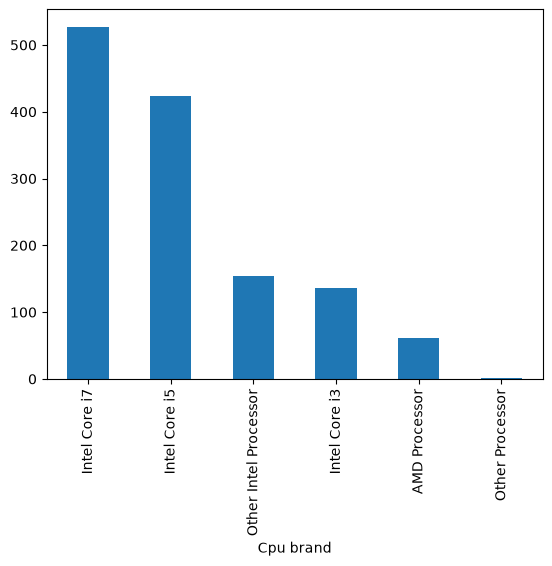

In [41]:
df['Cpu brand'].value_counts().plot(kind='bar') # Plot the count of laptops by CPU brand

In [42]:
df= df[~(df['Cpu brand'] == 'Other Processor')] # Delete rows where the 'Cpu brand' is 'Other Processor' to focus on the main CPU brands


Price Distribution Based on Processors:

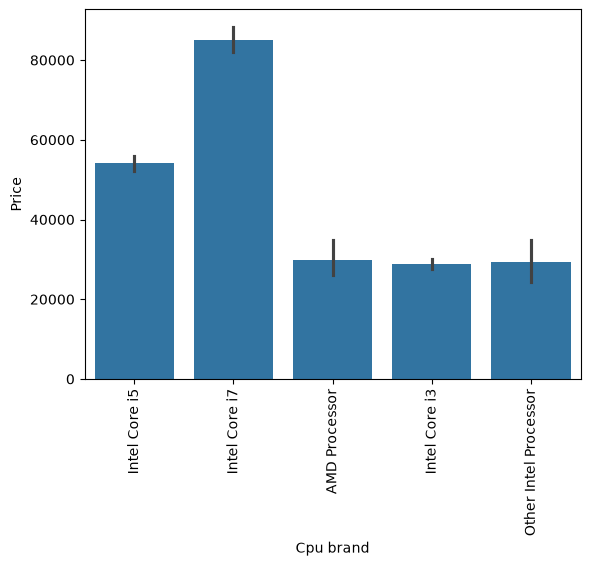

In [43]:
sns.barplot(x=df['Cpu brand'],y=df['Price']) # Create a bar plot of the average price of laptops by CPU brand
plt.xticks(rotation='vertical') # Rotate the x-axis labels for better readability
plt.show() # Display the plot

In [44]:
df.drop(columns=['Cpu','Cpu Name'], inplace=True) # Drop the 'Cpu' and 'Cpu Name' columns as they are no longer needed

In [45]:
df.head(4) # Display the first 4 rows of the DataFrame to verify the changes

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,Ips,ppi,Cpu brand
0,Apple,Ultrabook,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5
1,Apple,Ultrabook,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5
2,HP,Notebook,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5
3,Apple,Ultrabook,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7


In [46]:
# Rename of columns for better understanding
df.rename(columns={'TouchScreen': 'Touchscreen'}, inplace=True)

How Ram Affects on Price:

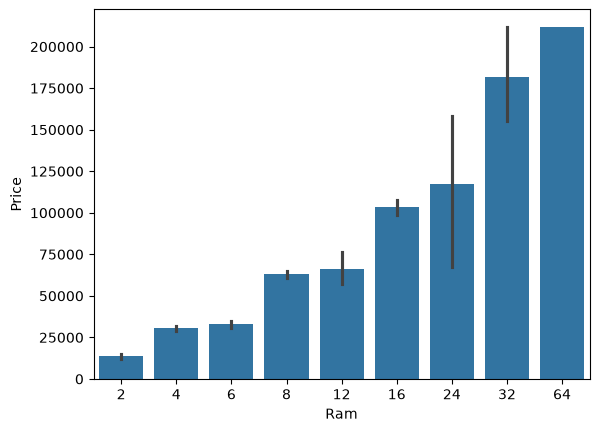

In [47]:
sns.barplot(x=df['Ram'],y=df['Price']) # Create a bar plot of the average price of laptops by Ram
plt.show() # Display the plot

Handling the Memory Column:

In [48]:
# Ensure Memory column is string and clean units
df['Memory'] = df['Memory'].astype(str).replace('\.0', '', regex=True)
df["Memory"] = df["Memory"].str.replace('GB', '')
df["Memory"] = df["Memory"].str.replace('TB', '000')

# Split into two parts
new = df["Memory"].str.split("+", n=1, expand=True)
df["first"] = new[0].str.strip()
df["second"] = new[1].fillna("0").astype(str).str.strip()

# Layer1 flags
df["Layer1HDD"] = df["first"].apply(lambda x: 1 if "HDD" in x else 0)
df["Layer1SSD"] = df["first"].apply(lambda x: 1 if "SSD" in x else 0)
df["Layer1Hybrid"] = df["first"].apply(lambda x: 1 if "Hybrid" in x else 0)
df["Layer1Flash_Storage"] = df["first"].apply(lambda x: 1 if "Flash Storage" in x else 0)

# Extract numeric part from first
df['first'] = df['first'].str.replace(r'\D', '', regex=True)

# Layer2 flags (now safe because second is string)
df["Layer2HDD"] = df["second"].apply(lambda x: 1 if "HDD" in x else 0)
df["Layer2SSD"] = df["second"].apply(lambda x: 1 if "SSD" in x else 0)
df["Layer2Hybrid"] = df["second"].apply(lambda x: 1 if "Hybrid" in x else 0)
df["Layer2Flash_Storage"] = df["second"].apply(lambda x: 1 if "Flash Storage" in x else 0)

# Extract numeric part from second
df['second'] = df['second'].str.replace(r'\D', '', regex=True)

# Convert to int safely
df["first"] = df["first"].replace('', '0').astype(int)
df["second"] = df["second"].replace('', '0').astype(int)

# Final numeric columns
df["HDD"] = df["first"]*df["Layer1HDD"] + df["second"]*df["Layer2HDD"]
df["SSD"] = df["first"]*df["Layer1SSD"] + df["second"]*df["Layer2SSD"]
df["Hybrid"] = df["first"]*df["Layer1Hybrid"] + df["second"]*df["Layer2Hybrid"]
df["Flash_Storage"] = df["first"]*df["Layer1Flash_Storage"] + df["second"]*df["Layer2Flash_Storage"]

# Drop helper columns
df.drop(columns=[
    'first','second',
    'Layer1HDD','Layer1SSD','Layer1Hybrid','Layer1Flash_Storage',
    'Layer2HDD','Layer2SSD','Layer2Hybrid','Layer2Flash_Storage'
], inplace=True)


In [49]:
df.head(4) # Display the first 4 rows of the DataFrame to verify the changes

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage
0,Apple,Ultrabook,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,0,0
1,Apple,Ultrabook,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,0,128
2,HP,Notebook,8,256 SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,0,0
3,Apple,Ultrabook,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,0,0


In [50]:
num_cols = ['Ram', 'Weight', 'ppi', 'HDD', 'SSD', 'Hybrid', 'Flash_Storage', 'Price']
df[num_cols].corr()['Price']


Ram              0.742905
Weight           0.209867
ppi              0.350885
HDD             -0.096891
SSD              0.670660
Hybrid           0.007942
Flash_Storage   -0.040067
Price            1.000000
Name: Price, dtype: float64

In [51]:
df.drop(columns=['Memory','Hybrid','Flash_Storage'], inplace=True) 

In [52]:
df.head()

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD
0,Apple,Ultrabook,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128
1,Apple,Ultrabook,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0
2,HP,Notebook,8,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256
3,Apple,Ultrabook,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512
4,Apple,Ultrabook,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256


Operations on GPU columns:

In [53]:
df['Gpu brand']= df['Gpu'].apply(lambda x: x.split()[0]) # Extract the first word from the 'Gpu' column and store it in a new column 'Gpu brand'
df.head(4) # Display the first 4 rows of the DataFrame to verify the changes

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Gpu brand
0,Apple,Ultrabook,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel
1,Apple,Ultrabook,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel
2,HP,Notebook,8,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,Intel
3,Apple,Ultrabook,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,AMD


<Axes: xlabel='Gpu brand'>

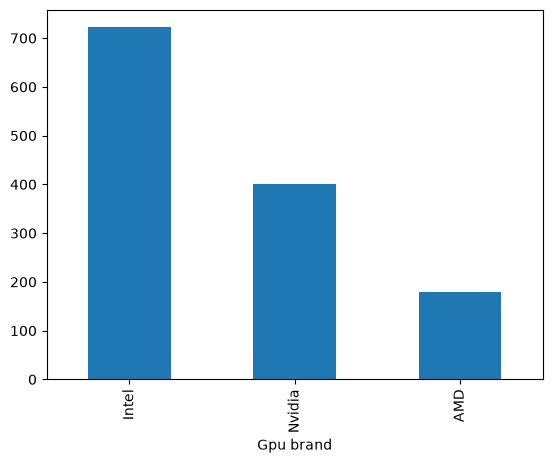

In [54]:
df['Gpu brand'].value_counts().plot(kind='bar') # Plot the count of laptops by GPU brand

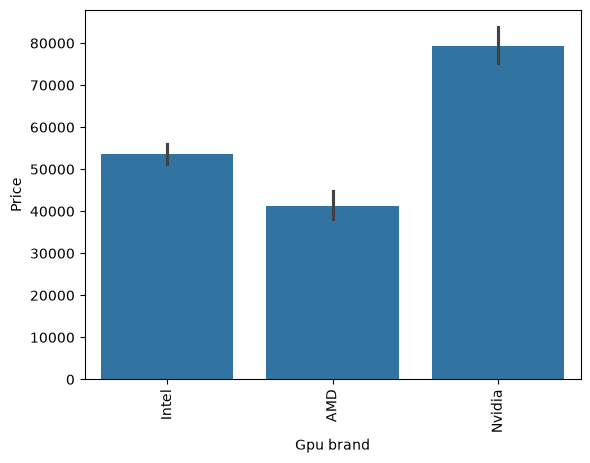

In [55]:
sns.barplot(x=df['Gpu brand'],y=df['Price']) # Create a bar plot of the average price of laptops by GPU brand
plt.xticks(rotation='vertical') # Rotate the x-axis labels for better readability
plt.show() # Display the plot

In [56]:
df.drop(columns=['Gpu'], inplace=True) # Drop the 'Gpu' column as it is no longer needed

In [57]:
df['OpSys'].value_counts() 

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         26
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

In [58]:
def fix_os(text):
    if text == 'Windows 10' or text == 'Windows 7' or text == 'Windows 11':
        return 'Windows'
    elif text == 'macOS' or text == 'Mac OS X':
        return 'Mac'
    elif text == 'Linux':
        return 'Linux'
    else:
        return 'Other'

In [59]:
df['os'] = df['OpSys'].apply(fix_os) # Apply the fix_os function to the 'OpSys' column and store the result in a new column 'os'

In [60]:
df.head() # Display the first few rows of the DataFrame to verify the changes

,Company,TypeName,Ram,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Gpu brand,os
0,Apple,Ultrabook,8,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,Intel,Other
3,Apple,Ultrabook,16,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,Intel,Mac


Which OS is used mostly?

<Axes: xlabel='os'>

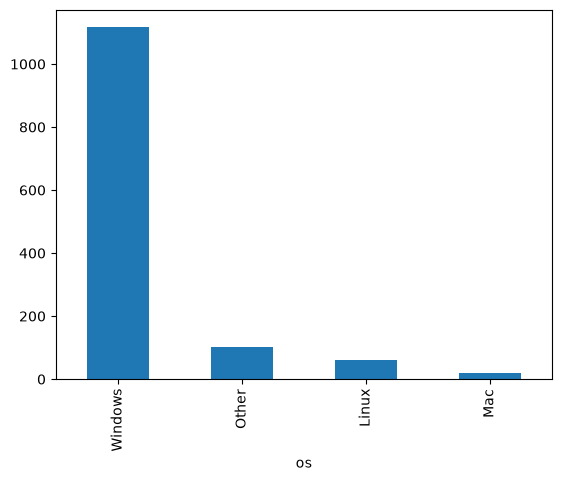

In [61]:
df['os'].value_counts().plot(kind='bar') # Plot the count of laptops by operating system

Find the most Frequent weight range:

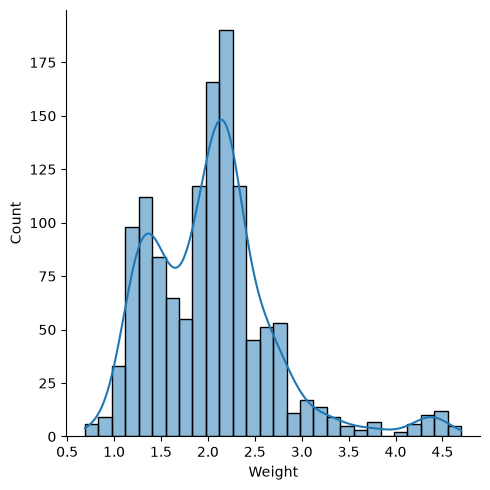

In [62]:
sns.displot(df['Weight'], kde=True) # Plot the distribution of the 'Weight' column with a kernel density estimate

Does weight of laptop related to price?

<Axes: xlabel='Weight', ylabel='Price'>

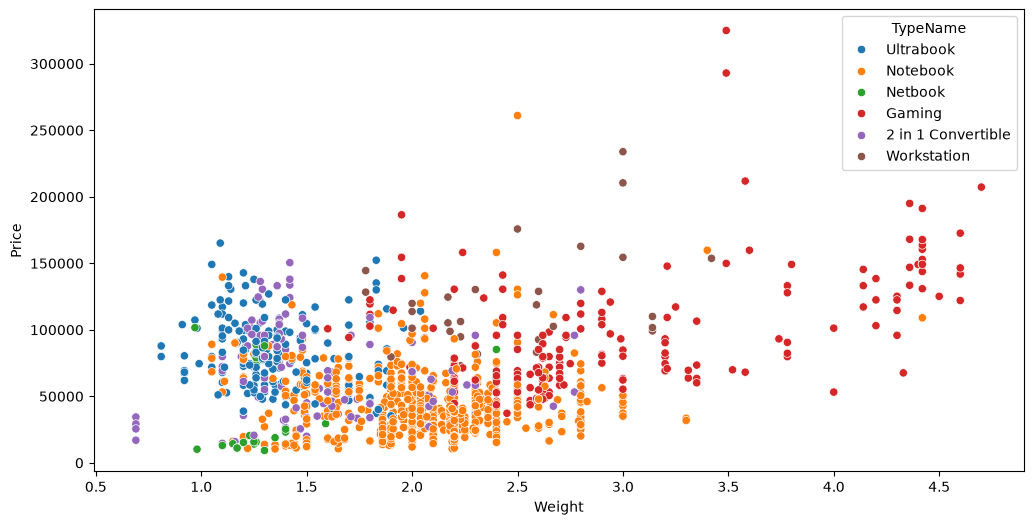

In [63]:
plt.figure(figsize=(12,6)) # Set the figure size for the scatter plot
sns.scatterplot(x=df['Weight'],y=df['Price'],hue=df['TypeName']) # Create a scatter plot of 'Weight' vs 'Price'

In [64]:
num_cols = ['Ram', 'Weight', 'ppi', 'HDD', 'SSD', 'Price']
df[num_cols].corr()['Price']

Ram       0.742905
Weight    0.209867
ppi       0.350885
HDD      -0.096891
SSD       0.670660
Price     1.000000
Name: Price, dtype: float64

# Model Pipeline Building and Finding the best Model:

In [65]:
x= df.drop(columns=['Price']).copy() # Create a new DataFrame 'x' by dropping the 'Price' column from the original DataFrame
y= df['Price'].copy() # Create a new Series 'y' that contains only the 'Price' column from the original DataFrame

In [66]:
x.head() # Display the first few rows of the DataFrame 'x' to verify the changes

,Company,TypeName,Ram,OpSys,Weight,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Gpu brand,os
0,Apple,Ultrabook,8,macOS,1.37,0,1,226.983005,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8,macOS,1.34,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8,No OS,1.86,0,0,141.211998,Intel Core i5,0,256,Intel,Other
3,Apple,Ultrabook,16,macOS,1.83,0,1,220.534624,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8,macOS,1.37,0,1,226.983005,Intel Core i5,0,256,Intel,Mac


In [67]:
y.head() # Display the first few rows of the Series 'y' to verify the changes

0     71378.6832
1     47895.5232
2     30636.0000
3    135195.3360
4     96095.8080
Name: Price, dtype: float64

In [68]:
x.head() # Display the first few rows of the 'x' DataFrame to verify the changes

,Company,TypeName,Ram,OpSys,Weight,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Gpu brand,os
0,Apple,Ultrabook,8,macOS,1.37,0,1,226.983005,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8,macOS,1.34,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8,No OS,1.86,0,0,141.211998,Intel Core i5,0,256,Intel,Other
3,Apple,Ultrabook,16,macOS,1.83,0,1,220.534624,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8,macOS,1.37,0,1,226.983005,Intel Core i5,0,256,Intel,Mac


In [69]:
x.drop(columns=['OpSys'], inplace=True) # Drop the 'OpSys' column from the 'x' DataFrame as it is no longer needed

In [70]:
x.info() # Display information about the 'x' DataFrame, including column names, data types, and non-null counts

<class 'pandas.DataFrame'>
Index: 1302 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Company      1302 non-null   str    
 1   TypeName     1302 non-null   str    
 2   Ram          1302 non-null   int64  
 3   Weight       1302 non-null   float64
 4   Touchscreen  1302 non-null   int64  
 5   Ips          1302 non-null   int64  
 6   ppi          1302 non-null   float64
 7   Cpu brand    1302 non-null   str    
 8   HDD          1302 non-null   int64  
 9   SSD          1302 non-null   int64  
 10  Gpu brand    1302 non-null   str    
 11  os           1302 non-null   str    
dtypes: float64(2), int64(5), str(5)
memory usage: 181.9 KB


In [71]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2, random_state=2) # Split the data into training and testing sets with 20% for testing

# Linear Regression:

In [72]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,AdaBoostRegressor,ExtraTreesRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [73]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler

In [74]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [77]:
# Categorical columns
categorical_cols = [
    'Company',
    'TypeName',
    'Cpu brand',
    'Gpu brand',
    'os'
]

# Numerical columns
numerical_cols = [
    'Ram',
    'Weight',
    'Touchscreen',
    'Ips',
    'ppi',
    'HDD',
    'SSD'
]

step1 = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(
            handle_unknown='ignore',
            drop='first',
            sparse_output=False
        ), categorical_cols)
    ],
    remainder='passthrough'
)

step2 = LinearRegression()

pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

pipe.fit(x_train, y_train)

y_pred = pipe.predict(x_test)

print('R2 score:', r2_score(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))

R2 score: 0.6968756023798719
MAE: 12925.582756565615
MSE: 323829179.31618106


# Random Forest Regressor:

In [79]:
# Categorical columns
categorical_cols = [
    'Company',
    'TypeName',
    'Cpu brand',
    'Gpu brand',
    'os'
]

# Numerical columns
numerical_cols = [
    'Ram',
    'Weight',
    'Touchscreen',
    'Ips',
    'ppi',
    'HDD',
    'SSD'
]

step1 = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(
            handle_unknown='ignore',
            drop='first',
            sparse_output=False
        ), categorical_cols)
    ],
    remainder='passthrough'
)

step2 = RandomForestRegressor()

pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

pipe.fit(x_train, y_train)

y_pred = pipe.predict(x_test)

print('R2 score:', r2_score(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))

R2 score: 0.7857487809618027
MAE: 9979.657132535087
MSE: 228885556.46905723


# Gradient Boost Regressor:

In [80]:
# Categorical columns
categorical_cols = [
    'Company',
    'TypeName',
    'Cpu brand',
    'Gpu brand',
    'os'
]

# Numerical columns
numerical_cols = [
    'Ram',
    'Weight',
    'Touchscreen',
    'Ips',
    'ppi',
    'HDD',
    'SSD'
]

step1 = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(
            handle_unknown='ignore',
            drop='first',
            sparse_output=False
        ), categorical_cols)
    ],
    remainder='passthrough'
)

step2 = GradientBoostingRegressor()

pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

pipe.fit(x_train, y_train)

y_pred = pipe.predict(x_test)

print('R2 score:', r2_score(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))

R2 score: 0.7937679942050058
MAE: 9903.12388093048
MSE: 220318594.31194887


# Adaptive Boosting:

In [81]:
# Categorical columns
categorical_cols = [
    'Company',
    'TypeName',
    'Cpu brand',
    'Gpu brand',
    'os'
]

# Numerical columns
numerical_cols = [
    'Ram',
    'Weight',
    'Touchscreen',
    'Ips',
    'ppi',
    'HDD',
    'SSD'
]

step1 = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(
            handle_unknown='ignore',
            drop='first',
            sparse_output=False
        ), categorical_cols)
    ],
    remainder='passthrough'
)

step2 = AdaBoostRegressor()

pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

pipe.fit(x_train, y_train)

y_pred = pipe.predict(x_test)

print('R2 score:', r2_score(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))

R2 score: 0.5054953804431415
MAE: 19461.36872343777
MSE: 528281545.0567497


# Optimal approach: Voting Regressor:

In [82]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    VotingRegressor
)

from xgboost import XGBRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)


# ============================================
# 2. DEFINE COLUMNS
# ============================================

categorical_cols = [
    'Company',
    'TypeName',
    'Touchscreen',
    'Ips',
    'Cpu brand',
    'Gpu brand',
    'os'
]


# ============================================
# 3. PREPROCESSING
# ============================================

step1 = ColumnTransformer(
    transformers=[
        (
            'col_tnf',
            OneHotEncoder(
                sparse_output=False,
                drop='first',
                handle_unknown='ignore'
            ),
            categorical_cols
        )
    ],
    remainder='passthrough'
)


# ============================================
# 4. DEFINE MODELS
# ============================================

# Random Forest
rf = RandomForestRegressor(
    n_estimators=350,
    random_state=3,
    max_samples=0.5,
    max_features=0.75,
    max_depth=15
)


# Gradient Boosting
gbdt = GradientBoostingRegressor(
    n_estimators=100,
    max_features=0.5,
    random_state=3
)


# XGBoost
xgb = XGBRegressor(
    n_estimators=25,
    learning_rate=0.3,
    max_depth=5,
    random_state=3
)


# Extra Trees
# bootstrap=True is IMPORTANT because
# max_samples=0.5 is being used
et = ExtraTreesRegressor(
    n_estimators=100,
    random_state=3,
    bootstrap=True,
    max_samples=0.5,
    max_features=0.75,
    max_depth=10
)


# ============================================
# 5. VOTING REGRESSOR
# ============================================

voting = VotingRegressor(
    [
        ('rf', rf),
        ('gbdt', gbdt),
        ('xgb', xgb),
        ('et', et)
    ],
    weights=[5, 1, 1, 1]
)


# ============================================
# 6. CREATE PIPELINE
# ============================================

pipe = Pipeline([
    ('step1', step1),
    ('step2', voting)
])


# ============================================
# 7. TRAIN MODEL
# ============================================

pipe.fit(x_train, y_train)


# ============================================
# 8. PREDICTION
# ============================================

y_pred = pipe.predict(x_test)


# ============================================
# 9. EVALUATION
# ============================================

print("Voting Regressor Results")
print("------------------------")

print("R2 Score:",
      r2_score(y_test, y_pred))

print("MAE:",
      mean_absolute_error(y_test, y_pred))

print("MSE:",
      mean_squared_error(y_test, y_pred))

Voting Regressor Results
------------------------
R2 Score: 0.8084273533926607
MAE: 9568.672243476878
MSE: 204657933.8955991


X_train
   ↓
OneHotEncoder
   ↓
Categorical → Numbers
   ↓
┌─────────────────────┐
│ Random Forest       │
│ Gradient Boosting   │
│ XGBoost             │
│ Extra Trees         │
└──────────┬──────────┘
           ↓
    Voting Regressor
           ↓
      Laptop Price

In [83]:
import pickle
pickle.dump(pipe, open('pipe.pkl', 'wb'))

In [84]:
pickle.dump(x,open('df.pkl', 'wb'))